08 - CUEC to client internal controls semantic mapping

In [1]:
# CONFIG CELL - Execution parameters and directory paths
import os
import sys
from pathlib import Path

# Enforce offline mode for Hugging Face to avoid network timeouts
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# Dynamically locate project root
CWD = Path(os.getcwd()).resolve()
if (CWD / "data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
elif (CWD / "socrr" / "data").exists():
    PROJECT_ROOT = CWD / "socrr"
else:
    PROJECT_ROOT = CWD

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_LABELED_DIR = PROJECT_ROOT / "data" / "labeled"
INTERNAL_CONTROLS_DIR = PROJECT_ROOT / "data" / "internal_controls"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for d in [DATA_INTERIM_DIR, DATA_LABELED_DIR, INTERNAL_CONTROLS_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[CONFIG] Project Root: {PROJECT_ROOT}")
print(f"[CONFIG] Models Dir:   {MODELS_DIR}")
print(f"[CONFIG] Outputs Dir:  {OUTPUTS_DIR}")

# Similarity Thresholds (Dense Embeddings vs TF-IDF)
MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_MATCHES = 3

[CONFIG] Project Root: D:\System and Organization controls 2 report info extraction
[CONFIG] Models Dir:   D:\System and Organization controls 2 report info extraction\models
[CONFIG] Outputs Dir:  D:\System and Organization controls 2 report info extraction\outputs


step 1 - lib & setup embedder

In [2]:
import json
import logging
from typing import List, Dict, Any, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("SOCRR_Mapping")

use_sentence_transformers = False
st_model = None

try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer(MODEL_NAME, local_files_only=True)
    use_sentence_transformers = True
    print(f"Loaded SentenceTransformer: {MODEL_NAME}")
except Exception as e:
    logger.info("Using local TF-IDF Semantic Cosine Similarity for offline embedding.")

# Calibrate thresholds adaptively based on vector representation
THRESHOLD_MAPPED = 0.65 if use_sentence_transformers else 0.25
THRESHOLD_PARTIAL = 0.45 if use_sentence_transformers else 0.12
print(f"Adaptive Thresholds: Mapped >= {THRESHOLD_MAPPED}, Partial >= {THRESHOLD_PARTIAL}")

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
2026-09-29 15:47:45,734 [INFO] TensorFlow version 2.21.0 available.
2026-09-29 15:47:47,530 [INFO] No device provided, using cpu
2026-09-29 15:47:47,568 [INFO] Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded SentenceTransformer: all-MiniLM-L6-v2
Adaptive Thresholds: Mapped >= 0.65, Partial >= 0.45


step 2 - embedding and mapping helper functions

functions to compute vector representations, calcuate top k similarities and assign mapping status

In [3]:
def get_embeddings(texts: List[str]) -> np.ndarray:
    """Compute normalized semantic embeddings with fallback support."""
    if use_sentence_transformers and st_model is not None:
        emb = st_model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
        return emb
    else:
        vec = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
        matrix = vec.fit_transform(texts).toarray()
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        return matrix / norms

def map_cuecs_to_client_controls(
    cuecs: List[Dict[str, Any]], 
    client_controls_df: pd.DataFrame,
    threshold_mapped: float = THRESHOLD_MAPPED,
    threshold_partial: float = THRESHOLD_PARTIAL,
    top_k: int = TOP_K_MATCHES
) -> Tuple[pd.DataFrame, np.ndarray]:
    """Rank top matches for each CUEC and flag compliance gaps."""
    cuec_texts = [c["text"] for c in cuecs]
    ctrl_texts = (client_controls_df["control_title"] + ": " + client_controls_df["control_description"]).tolist()
    
    all_texts = cuec_texts + ctrl_texts
    all_embs = get_embeddings(all_texts)
    
    cuec_embs = all_embs[:len(cuec_texts)]
    ctrl_embs = all_embs[len(cuec_texts):]
    
    sim_matrix = cosine_similarity(cuec_embs, ctrl_embs)
    
    mapping_results = []
    
    for i, cuec in enumerate(cuecs):
        scores = sim_matrix[i]
        top_indices = np.argsort(scores)[::-1][:top_k]
        best_idx = top_indices[0]
        best_score = float(scores[best_idx])
        
        if best_score >= threshold_mapped:
            status = "Mapped"
        elif best_score >= threshold_partial:
            status = "Partially Mapped"
        else:
            status = "Gap"
            
        best_ctrl = client_controls_df.iloc[best_idx]
        
        top_matches_summary = []
        for idx in top_indices:
            row = client_controls_df.iloc[idx]
            top_matches_summary.append(f"{row['control_id']} ({scores[idx]:.2f}): {row['control_title']}")
            
        mapping_results.append({
            "cuec_id": cuec.get("id", f"CUEC-{i+1:02d}"),
            "cuec_category": cuec.get("category", "general"),
            "cuec_text": cuec["text"],
            "mapped_control_id": best_ctrl["control_id"] if status != "Gap" else "NONE",
            "mapped_control_title": best_ctrl["control_title"] if status != "Gap" else "NONE",
            "similarity_score": round(best_score, 3),
            "status": status,
            "top_3_matches": " | ".join(top_matches_summary)
        })
        
    return pd.DataFrame(mapping_results), sim_matrix

step 3 - load client controls and execute emantic mapping

Loaded 15 client internal controls:


,control_id,domain,control_title,control_description
0,INT-AC-01,Access Control,Multi-Factor Authentication (MFA),User entities and internal personnel must enfo...
1,INT-AC-02,Access Control,Periodic Access Reviews,User access permissions and administrative pri...
2,INT-AC-03,Access Control,Timely Deprovisioning,Access rights of terminated employees and cont...
3,INT-AC-04,Access Control,Password Complexity Policy,Passwords must be a minimum of 14 characters i...
4,INT-CM-01,Change Management,Peer Code Review,All source code changes to production systems ...



Processing CUECs from 2 reports...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[sample_soc_report] Saved mapping Excel to D:\System and Organization controls 2 report info extraction\outputs\sample_soc_report_cuec_mapping.xlsx


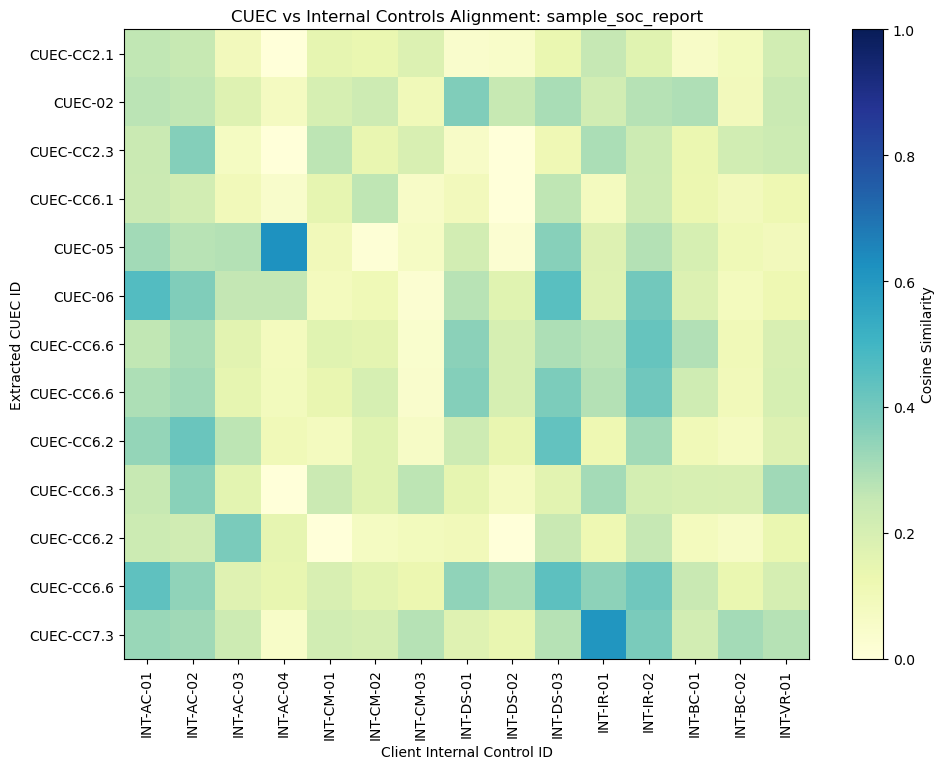

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[synthetic_acme_soc2] Saved mapping Excel to D:\System and Organization controls 2 report info extraction\outputs\synthetic_acme_soc2_cuec_mapping.xlsx


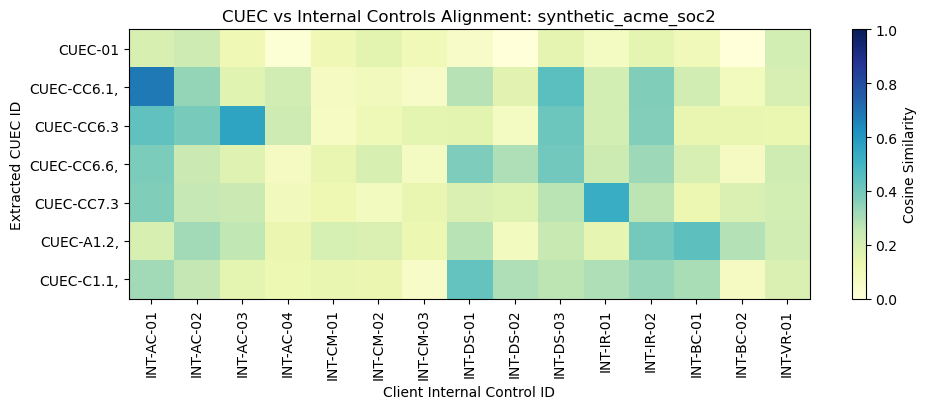


CUEC Compliance Mapping Breakdown:
status
Gap                 14
Partially Mapped     5
Mapped               1
Name: count, dtype: int64


,report_id,cuec_id,status,similarity_score,mapped_control_id,mapped_control_title
0,sample_soc_report,CUEC-CC2.1,Gap,0.261,NONE,NONE
1,sample_soc_report,CUEC-02,Gap,0.371,NONE,NONE
2,sample_soc_report,CUEC-CC2.3,Gap,0.364,NONE,NONE
3,sample_soc_report,CUEC-CC6.1,Gap,0.266,NONE,NONE
4,sample_soc_report,CUEC-05,Partially Mapped,0.620,INT-AC-04,Password Complexity Policy
5,sample_soc_report,CUEC-06,Partially Mapped,0.463,INT-AC-01,Multi-Factor Authentication (MFA)
6,sample_soc_report,CUEC-CC6.6,Gap,0.423,NONE,NONE
7,sample_soc_report,CUEC-CC6.6,Gap,0.405,NONE,NONE
8,sample_soc_report,CUEC-CC6.2,Gap,0.432,NONE,NONE
9,sample_soc_report,CUEC-CC6.3,Gap,0.357,NONE,NONE


In [5]:
controls_csv_path = INTERNAL_CONTROLS_DIR / "controls.csv"
client_controls = pd.read_csv(controls_csv_path)
print(f"Loaded {len(client_controls)} client internal controls:")
display(client_controls.head(5))

cuec_files = list(DATA_INTERIM_DIR.glob("*_subservice_cuec.json"))
print(f"\nProcessing CUECs from {len(cuec_files)} reports...")

all_mappings = []

for cf in cuec_files:
    report_id = cf.name.replace("_subservice_cuec.json", "")
    with open(cf, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    cuecs = data.get("cuecs", [])
    if not cuecs:
        print(f"[{report_id}] No CUECs found, skipping.")
        continue
        
    df_map, sim_mat = map_cuecs_to_client_controls(cuecs, client_controls)
    df_map["report_id"] = report_id
    all_mappings.append(df_map)
    
    excel_out = OUTPUTS_DIR / f"{report_id}_cuec_mapping.xlsx"
    with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
        df_map.to_excel(writer, sheet_name="CUEC Mapping", index=False)
        client_controls.to_excel(writer, sheet_name="Client Internal Controls", index=False)
    print(f"[{report_id}] Saved mapping Excel to {excel_out}")
    
    plt.figure(figsize=(10, max(4, len(cuecs) * 0.6)))
    plt.imshow(sim_mat, cmap="YlGnBu", aspect="auto", vmin=0.0, vmax=1.0)
    plt.colorbar(label="Cosine Similarity")
    plt.yticks(range(len(cuecs)), [c.get("id", f"CUEC-{idx+1}") for idx, c in enumerate(cuecs)])
    plt.xticks(range(len(client_controls)), client_controls["control_id"], rotation=90)
    plt.title(f"CUEC vs Internal Controls Alignment: {report_id}")
    plt.xlabel("Client Internal Control ID")
    plt.ylabel("Extracted CUEC ID")
    plt.tight_layout()
    heatmap_path = OUTPUTS_DIR / f"cuec_heatmap_{report_id}.png"
    plt.savefig(heatmap_path, dpi=200)
    plt.show()

if all_mappings:
    df_all_map = pd.concat(all_mappings, ignore_index=True)
    df_all_map.to_csv(OUTPUTS_DIR / "cuec_mapping_summary.csv", index=False)
    print("\nCUEC Compliance Mapping Breakdown:")
    print(df_all_map["status"].value_counts())
    display(df_all_map[["report_id", "cuec_id", "status", "similarity_score", "mapped_control_id", "mapped_control_title"]])

step 4 - check

In [6]:
assert (OUTPUTS_DIR / "cuec_mapping_summary.csv").exists()
for cf in cuec_files:
    rep_id = cf.name.replace("_subservice_cuec.json", "")
    assert (OUTPUTS_DIR / f"{rep_id}_cuec_mapping.xlsx").exists()

print("Sanity Check Passed: CUEC to client internal controls mapping complete.")

Sanity Check Passed: CUEC to client internal controls mapping complete.
